# Rapalog Discovery Pipeline
## 02 Fragment and Similarity notebook
### **Phase 2: Exploratory Data Analysis and Similarity Workflow**
#### **Part 1: Characterize Rapamycin Binding Fragment and Candidate Molecules**
A. Load FKBP12-rapamycin structure (CIF file)
B. Inspect rapamycin structure
C. Identify contact atoms
D. Build interaction map
E. Classify interactions
F. Extract rapamycin pharmacophore atoms
G. Load full FKBP12-Rapamycin structure in RDKit (PDB file)
H. Identify rapamycin atoms in RDKit
I. Map rapamycin pharmacophore atoms to interation map RDKit indices
J. Extract binding fragment from rapamycin binding region
K. Sanitize fragment
L. Load Coconut dataset
M. Convert SMILES to RDKit molecules
N. Prefilter Coconut dataset molecules

#### **Part 2: Morgan fingerprints and similarity scoring**
A. Compute candidates' morgan fingerprint and similarity scores 
B. Review candidates by similarity
C. Compare Tanimoto and Tversky similarity methods
D. Rank candidates by similarity

In [16]:
# Setup: paths, imports, and runtime flags
import numpy as np
import sys
import importlib
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
config = importlib.reload(config)

import src.fragment_extraction as fragment_extraction
importlib.reload(fragment_extraction)

from src.fragment_extraction import (
    load_fkbp12_structure,
    identify_contact_atoms,
    build_interaction_map,
    classify_interactions,
    extract_pharmacophore_atoms,
    load_full_structure_rdkit,
    identify_rapamycin_atom_indices,
    map_pharmacophore_to_rdkit_indices,
    extract_binding_fragment,
    load_coconut_subset,
    load_or_build_molecules,
    prefilter_molecules,
    )
from src.fingerprints import get_fp_from_mole
from src.similarity import (
    rank_candidates,
    compare_similarity_metrics,
    load_or_compute_similarity_scores,
    )

raw_dir = PROJECT_ROOT / "data" / "raw"
cif_path = raw_dir / "1FKB.cif"
pdb_path = raw_dir / "1FKB.pdb"
coconut_csv_path = raw_dir / "coconut_csv-04-2026.csv"

molecules_cache_path = raw_dir / config.MOLECULES_CACHE_FILE
filtered_cache_path = raw_dir / config.FILTERED_MOLECULES_CACHE_FILE
similarity_cache_path = raw_dir / config.SIMILARITY_SCORES_CACHE_FILE

print("Config module file:", config.__file__)
print("Project root:", PROJECT_ROOT)
print("RUN_FRAGMENT_EXTRACTION:", config.RUN_FRAGMENT_EXTRACTION)
print("RUN_COCONUT_PREP:", config.RUN_COCONUT_PREP)
print("RUN_FULL_SIMILARITY:", config.RUN_FULL_SIMILARITY)

Config module file: /Users/alangale/Projects/rapalog-discovery-pipeline/src/config.py
Project root: /Users/alangale/Projects/rapalog-discovery-pipeline
RUN_FRAGMENT_EXTRACTION: True
RUN_COCONUT_PREP: True
RUN_FULL_SIMILARITY: True


In [4]:
# P1.A-P1.K: Build rapamycin binding fragment
if config.RUN_FRAGMENT_EXTRACTION:
    structure, model = load_fkbp12_structure(str(cif_path))
    contact_atoms, neighbor_search = identify_contact_atoms(
        structure=structure,
        model=model,
        distance=3.5,
    )
    interaction_map = build_interaction_map(
        contact_atoms=contact_atoms,
        neighbor_search=neighbor_search,
        distance=3.5,
    )
    interaction_groups = classify_interactions(interaction_map)
    pharmacophore_atoms = extract_pharmacophore_atoms(
        contact_atoms=contact_atoms,
        hbond_interactions=interaction_groups["hbond_interactions"],
        hydrophobic_interactions=interaction_groups["hydrophobic_interactions"],
        polar_interactions=interaction_groups["polar_interactions"],
    )

    full_structure = load_full_structure_rdkit(str(pdb_path), remove_hs=False)
    rapa_atom_indices = identify_rapamycin_atom_indices(full_structure)
    rdkit_pharmacophore_indices = map_pharmacophore_to_rdkit_indices(
        full_structure,
        pharmacophore_atoms,
    )
    binding_fragment = extract_binding_fragment(
        full_structure,
        rdkit_pharmacophore_indices,
        sanitize=True,
    )

    print("Contact atoms:", len(contact_atoms))
    print("Interactions:", len(interaction_map))
    print("Pharmacophore atoms:", len(pharmacophore_atoms))
    print("RAP atom indices:", len(rapa_atom_indices))
    print("Mapped pharmacophore indices:", len(rdkit_pharmacophore_indices))
    print("Binding fragment atoms:", binding_fragment.GetNumAtoms())

    binding_fp_r1 = get_fp_from_mole(binding_fragment, radius=1)
    binding_fp_r2 = get_fp_from_mole(binding_fragment, radius=2)
    print(
        "Binding fragment fingerprint bits (r1, r2):",
        binding_fp_r1.GetNumOnBits(),
        binding_fp_r2.GetNumOnBits(),
    )
else:
    binding_fragment = None
    print("Skipped fragment extraction (RUN_FRAGMENT_EXTRACTION=False).")

Contact atoms: 20
Interactions: 40
Pharmacophore atoms: 10
RAP atom indices: 68
Mapped pharmacophore indices: 10
Binding fragment atoms: 15
Binding fragment fingerprint bits (r1, r2): 12 13


[14:27:38] DEPRECATION WARNING: please use MorganGenerator
[14:27:38] DEPRECATION WARNING: please use MorganGenerator


In [5]:
# P1.L-P1.N: Prepare COCONUT molecules (with cache hooks)
if config.RUN_COCONUT_PREP:
    coconut_df = load_coconut_subset(str(coconut_csv_path))
    molecules, invalid_count = load_or_build_molecules(
        coconut_df=coconut_df,
        pickle_path=str(molecules_cache_path),
        rebuild=config.REBUILD_MOLECULES,
    )

    if (not config.REBUILD_MOLECULES_FILTERED) and filtered_cache_path.exists():
        with open(filtered_cache_path, "rb") as f:
            filtered = pickle.load(f)
    else:
        filtered = prefilter_molecules(
            molecules=molecules,
            filters=config.RAPAMYCIN_PREFILTERS,
        )
        with open(filtered_cache_path, "wb") as f:
            pickle.dump(filtered, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("COCONUT rows:", len(coconut_df))
    print("Valid molecules:", len(molecules))
    print("Invalid SMILES skipped:", invalid_count)
    print("Prefilter settings:", config.RAPAMYCIN_PREFILTERS)
    print("Filtered molecules:", len(filtered))
else:
    coconut_df = None
    molecules = None
    filtered = None
    print("Skipped COCONUT prep (RUN_COCONUT_PREP=False).")


/Users/alangale/Projects/rapalog-discovery-pipeline/src/fragment_extraction.py:196: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  coconut = pd.read_csv(csv_path)


COCONUT rows: 738827
Valid molecules: 738823
Invalid SMILES skipped: 0
Prefilter settings: {'mw_min': 350, 'mw_max': 700, 'hba_min': 3, 'hba_max': 8, 'hbd_min': 1, 'hbd_max': 4, 'logp_min': 2, 'logp_max': 5, 'rings_min': 2, 'rings_max': 5, 'tpsa_max': 150}
Filtered molecules: 96682


In [6]:
# P2.A-P2.D: Compute similarity, compare metrics, and rank candidates
if config.RUN_FULL_SIMILARITY:
    if binding_fragment is None:
        raise ValueError("binding_fragment is None. Enable RUN_FRAGMENT_EXTRACTION first.")
    if filtered is None:
        raise ValueError("filtered is None. Enable RUN_COCONUT_PREP first.")

    results_df = load_or_compute_similarity_scores(
        molecules=filtered,
        binding_fragment=binding_fragment,
        pickle_path=str(similarity_cache_path),
        rebuild=config.REBUILD_SIMILARITY_SCORES,
    )

    results_df = results_df.drop_duplicates(subset=["smiles"]).copy()
    results_df["name"] = results_df["name"].fillna(results_df["coconut_id"])

    ranked_df = rank_candidates(results_df, by="sim_tv_frag", ascending=False)
    top_n_df = rank_candidates(
        results_df,
        by="sim_tv_frag",
        ascending=False,
        top_n=config.TOP_N_CANDIDATES,
    )
    metric_summary = compare_similarity_metrics(results_df)

    print("Results rows:", len(results_df))
    print("Ranked rows:", len(ranked_df))
    print(f"Top {config.TOP_N_CANDIDATES} rows:", len(top_n_df))
    print("Metric summary:", metric_summary)
else:
    results_df = None
    ranked_df = None
    top_n_df = None
    print("Skipped similarity workflow (RUN_FULL_SIMILARITY=False).")

Results rows: 96682
Ranked rows: 96682
Top 5000 rows: 5000
Metric summary: {'corr_all': 0.9714625615974399, 'corr_top_5000': 0.7861104550522924, 'max_tanimoto': 0.5714285714285714, 'max_tversky_fragment': 0.7843137254901962}


Saved: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_02/similarity_metric_summary_table.csv


,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag
count,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000
mean,0.193755,0.193744,0.112266,0.320702,0.320684,0.200575,0.265119,0.265116,0.142461
std,0.057559,0.057580,0.029883,0.081325,0.081364,0.048227,0.072868,0.072874,0.035747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.156250,0.156250,0.093023,0.270270,0.270270,0.170213,0.218579,0.218579,0.119617
50%,0.200000,0.200000,0.113208,0.333333,0.333333,0.203390,0.265152,0.265152,0.143541
75%,0.230769,0.230769,0.130435,0.375000,0.375000,0.230769,0.319635,0.319635,0.164835
max,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540


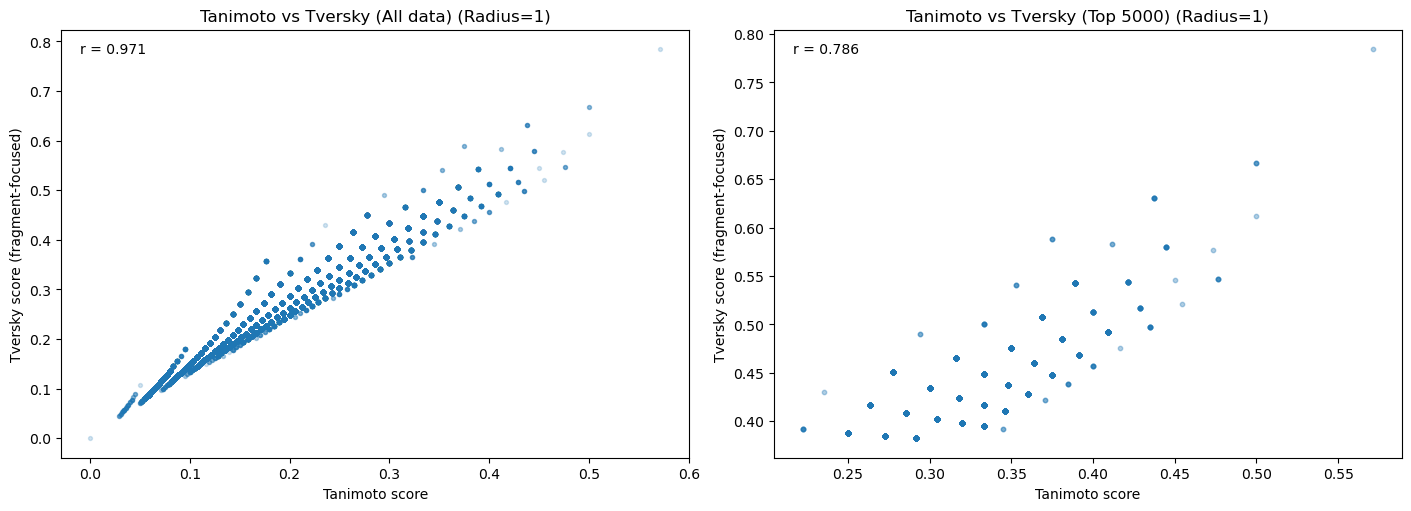

Saved: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_02/tanimoto_vs_tversky_radius1_all_and_top5000.png


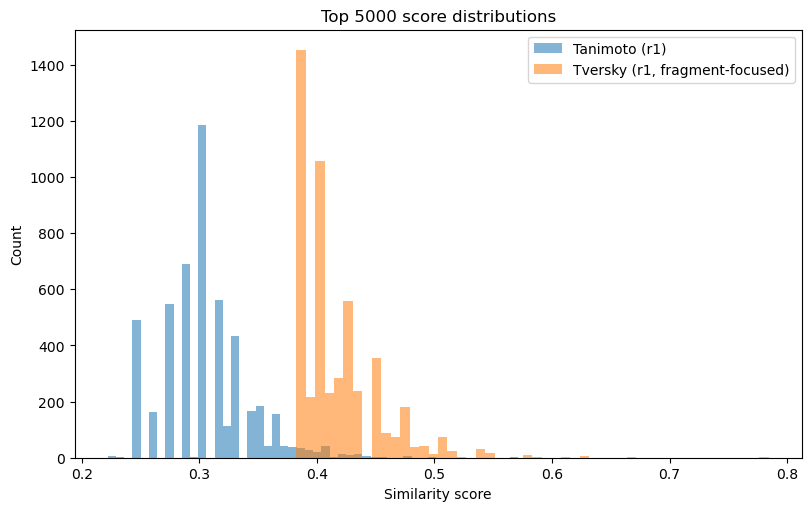

Saved: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_02/top5000_tanimoto_vs_tversky_score_distribution.png


In [ ]:
# P2.E-P2.E: Similarity comparison tables and plots (display + save)
if results_df is None or top_n_df is None:
    raise ValueError("Run Cell 5 first to compute results_df and top_n_df.")

results_dir = PROJECT_ROOT / "results" / "notebook_02"
results_dir.mkdir(parents=True, exist_ok=True)

# Match Project2 table layout and metric ordering.
metric_cols = [
    "sim_tanimoto",
    "sim_r1_tan",
    "sim_r2_tan",
    "sim_tv_sym",
    "sim_r1_tv_sym",
    "sim_r2_tv_sym",
    "sim_tv_frag",
    "sim_r1_tv_frag",
    "sim_r2_tv_frag",
]

comparison_table = results_df[metric_cols].describe()
comparison_table_path = results_dir / "similarity_metric_summary_table.csv"
comparison_table.to_csv(comparison_table_path)

print("Saved:", comparison_table_path)
display(comparison_table)

corr_all = results_df["sim_r1_tan"].corr(results_df["sim_r1_tv_frag"])
corr_top = top_n_df["sim_r1_tan"].corr(top_n_df["sim_r1_tv_frag"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].scatter(results_df["sim_r1_tan"], results_df["sim_r1_tv_frag"], alpha=0.2, s=8)
axes[0].set_title("Tanimoto vs Tversky (All data) (Radius=1)")
axes[0].set_xlabel("Tanimoto score")
axes[0].set_ylabel("Tversky score (fragment-focused)")
axes[0].text(
    0.03,
    0.97,
    f"r = {corr_all:.3f}",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)

axes[1].scatter(top_n_df["sim_r1_tan"], top_n_df["sim_r1_tv_frag"], alpha=0.35, s=10)
axes[1].set_title(f"Tanimoto vs Tversky (Top {config.TOP_N_CANDIDATES}) (Radius=1)")
axes[1].set_xlabel("Tanimoto score")
axes[1].set_ylabel("Tversky score (fragment-focused)")
axes[1].text(
    0.03,
    0.97,
    f"r = {corr_top:.3f}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)

scatter_path = results_dir / "tanimoto_vs_tversky_radius1_all_and_top5000.png"
fig.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", scatter_path)

fig2, ax2 = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax2.hist(top_n_df["sim_r1_tan"], bins=50, alpha=0.55, label="Tanimoto (r1)")
ax2.hist(top_n_df["sim_r1_tv_frag"], bins=50, alpha=0.55, label="Tversky (r1, fragment-focused)")
ax2.set_title(f"Top {config.TOP_N_CANDIDATES} score distributions")
ax2.set_xlabel("Similarity score")
ax2.set_ylabel("Count")
ax2.legend()

hist_path = results_dir / "top5000_tanimoto_vs_tversky_score_distribution.png"
fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", hist_path)

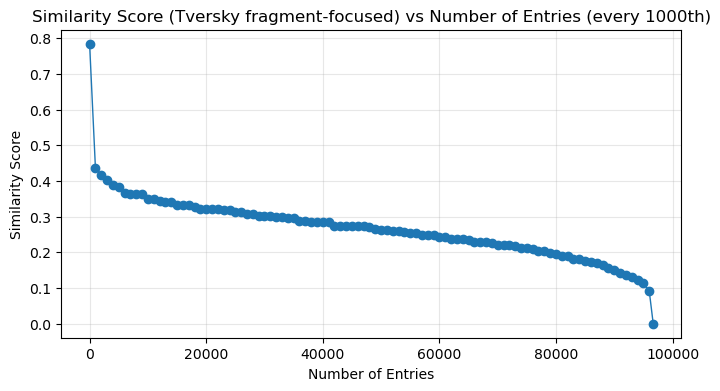

Saved: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_02/similarity_vs_entries_every_1000.png
Total ranked entries: 96682
Points plotted (all-ranked): 98 (step=1000)


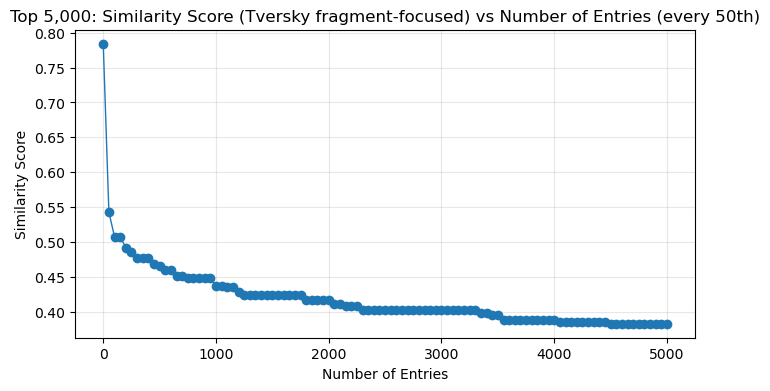

Saved: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_02/top5000_similarity_vs_entries_every_50.png
Focused range: top 5000 entries
Points plotted (top-5,000): 101 (step=50)
Subset size: 5000


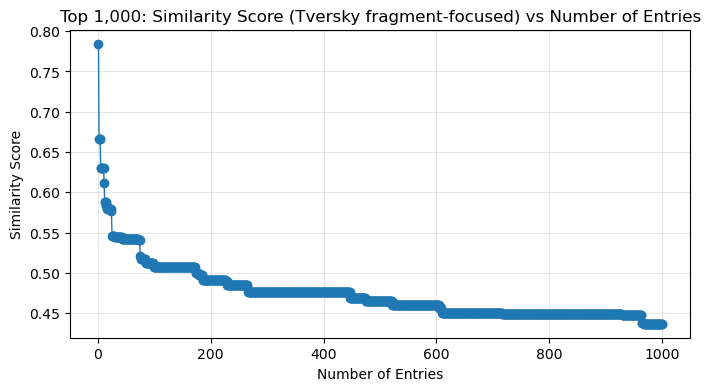

Saved: /Users/alangale/Projects/rapalog-discovery-pipeline/results/notebook_02/top1000_similarity_vs_entries.png
Focused range: top 1000 entries
Points plotted (top-1,000): 1000 (step=1)
Subset size: 1000


In [21]:
# P2.F Rank candidates by similarity
# Rank all candidates by similarity score (highest first)
results_ranked = (
    results_df.sort_values(by="sim_tv_frag", ascending=False)
    .reset_index(drop=True)
    .copy()
)
results_ranked["entry_n"] = np.arange(1, len(results_ranked) + 1)

# Plot 1: all ranked entries, sampled every 1000
plot_step = 1000
plot_df = results_ranked.iloc[::plot_step].copy()

# Include the last entry if it is not already included by stepping
if plot_df.iloc[-1]["entry_n"] != results_ranked.iloc[-1]["entry_n"]:
    plot_df = pd.concat([plot_df, results_ranked.tail(1)], ignore_index=True)

fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(plot_df["entry_n"], plot_df["sim_tv_frag"], marker="o", linewidth=1)
ax1.set_title("Similarity Score (Tversky fragment-focused) vs Number of Entries (every 1000th)")
ax1.set_xlabel("Number of Entries")
ax1.set_ylabel("Similarity Score")
ax1.grid(alpha=0.3)

plot1_path = results_dir / "similarity_vs_entries_every_1000.png"
fig1.savefig(plot1_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot1_path)

print(f"Total ranked entries: {len(results_ranked)}")
print(f"Points plotted (all-ranked): {len(plot_df)} (step={plot_step})")

# Plot 2: focused on top 5,000, sampled every 50
top_n_focus = 5000
focus_step = 50
results_top_focus = results_ranked.head(top_n_focus).copy()
focus_plot_df = results_top_focus.iloc[::focus_step].copy()

# Include the last top-N entry if not already included
if focus_plot_df.iloc[-1]["entry_n"] != results_top_focus.iloc[-1]["entry_n"]:
    focus_plot_df = pd.concat([focus_plot_df, results_top_focus.tail(1)], ignore_index=True)

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(focus_plot_df["entry_n"], focus_plot_df["sim_tv_frag"], marker="o", linewidth=1)
ax2.set_title("Top 5,000: Similarity Score (Tversky fragment-focused) vs Number of Entries (every 50th)")
ax2.set_xlabel("Number of Entries")
ax2.set_ylabel("Similarity Score")
ax2.grid(alpha=0.3)

plot2_path = results_dir / "top5000_similarity_vs_entries_every_50.png"
fig2.savefig(plot2_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot2_path)

print(f"Focused range: top {len(results_top_focus)} entries")
print(f"Points plotted (top-5,000): {len(focus_plot_df)} (step={focus_step})")

# Keep top 5000 candidates for downstream Phase 2 cells
results_df_top = results_ranked.head(5000).copy()
print("Subset size:", len(results_df_top))

# Plot 3: focused on top 1,000, sampled every 10
top_n_focus = 1000
focus_step = 1
results_top_focus = results_ranked.head(top_n_focus).copy()
focus_plot_df = results_top_focus.iloc[::focus_step].copy()

# Include the last top-N entry if not already included
if focus_plot_df.iloc[-1]["entry_n"] != results_top_focus.iloc[-1]["entry_n"]:
    focus_plot_df = pd.concat([focus_plot_df, results_top_focus.tail(1)], ignore_index=True)

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(focus_plot_df["entry_n"], focus_plot_df["sim_tv_frag"], marker="o", linewidth=1)
ax3.set_title("Top 1,000: Similarity Score (Tversky fragment-focused) vs Number of Entries")
ax3.set_xlabel("Number of Entries")
ax3.set_ylabel("Similarity Score")
ax3.grid(alpha=0.3)

plot3_path = results_dir / "top1000_similarity_vs_entries.png"
fig3.savefig(plot3_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot3_path)

print(f"Focused range: top {len(results_top_focus)} entries")
print(f"Points plotted (top-1,000): {len(focus_plot_df)} (step={focus_step})")

# Decide how many to keep for further analyis
# Keep top 1000 candidates for downstream Phase 2 cells
results_df_top = results_ranked.head(1000).copy()
print("Subset size:", len(results_df_top))
